# Brouillon 2 : le confondeur (glaces, noyades, température)

Notebook d'exploration avant de ranger le code dans `src/`.
Vérité simulée : la température cause les glaces et les noyades, **les glaces n'ont aucun effet** sur les noyades.

In [1]:
import time
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import doubleml as dml

## 1. Simulation

In [2]:
def simuler(n=5000, effet=0.0, seed=123):
    rng = np.random.default_rng(seed)
    temperature = rng.normal(20, 6, n)
    glaces = 2 * temperature + 0.05 * temperature**2 + rng.normal(0, 5, n)
    noyades = 0.3 * temperature + 0.01 * temperature**2 + effet * glaces + rng.normal(0, 2, n)
    return pd.DataFrame({"temperature": temperature, "glaces": glaces, "noyades": noyades})

df = simuler()
df.describe().round(2)

,temperature,glaces,noyades
count,5000.00,5000.00,5000.00
mean,20.03,61.99,10.40
std,6.01,24.56,4.68
min,-1.40,-2.91,-3.71
25%,15.97,44.62,7.07
50%,20.04,60.11,10.17
75%,24.17,77.62,13.43
max,38.98,151.76,30.21


In [3]:
df.corr().round(3)

,temperature,glaces,noyades
temperature,1.000,0.974,0.897
glaces,0.974,1.000,0.887
noyades,0.897,0.887,1.000


Corrélation glaces-noyades très forte alors que l'effet vrai est nul. Normal : les deux dépendent de la température.

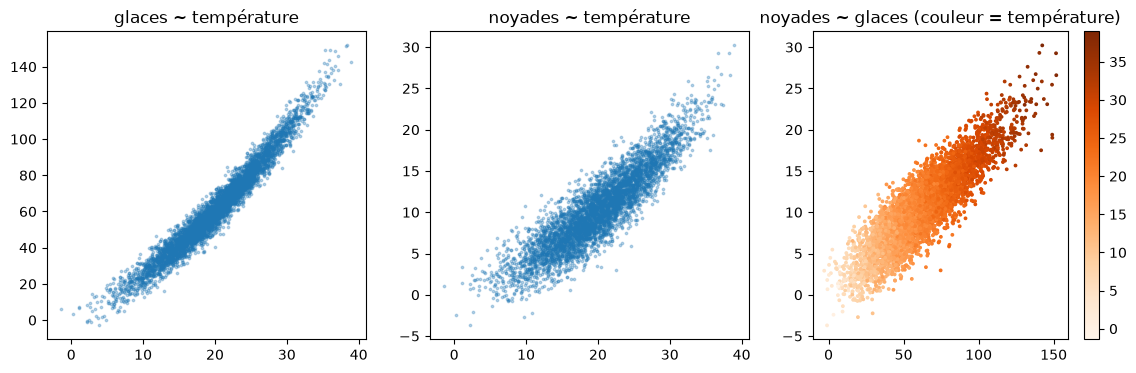

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(df.temperature, df.glaces, s=3, alpha=0.3)
axes[0].set_title("glaces ~ température")
axes[1].scatter(df.temperature, df.noyades, s=3, alpha=0.3)
axes[1].set_title("noyades ~ température")
sc = axes[2].scatter(df.glaces, df.noyades, s=3, c=df.temperature, cmap="Oranges")
axes[2].set_title("noyades ~ glaces (couleur = température)")
plt.colorbar(sc, ax=axes[2])
plt.show()

Sur le 3e graphique on voit que la « pente » vient du gradient de couleur, donc de la température.

Note : quelques températures négatives (20 - 3×6 = 2, donc rare mais possible) et quelques ventes de glaces
négatives. Ça n'a pas de sens physique, mais ça ne change rien à la démonstration. Je garde la spécification
de l'énoncé telle quelle.

In [5]:
print("températures < 0 :", (df.temperature < 0).sum(), " glaces < 0 :", (df.glaces < 0).sum())

températures < 0 : 1  glaces < 0 : 4


## 2. Effet « vrai » apparent de la confusion
Pente attendue de noyades sur glaces si on ignore la température, approximation au point moyen :
d(noyades)/dT ÷ d(glaces)/dT = (0.3 + 0.02·T) / (2 + 0.1·T) à T = 20.

In [6]:
(0.3 + 0.02 * 20) / (2 + 0.1 * 20)

0.175

## 3. Gradient Boosting naïf : noyades ~ glaces

In [7]:
X_naif = df[["glaces"]]
y = df["noyades"]
gb = GradientBoostingRegressor(random_state=0)
cv = KFold(5, shuffle=True, random_state=0)
r2_cv = cross_val_score(gb, X_naif, y, cv=cv, scoring="r2")
print("R² CV :", r2_cv.round(3), "moyenne :", r2_cv.mean().round(3))

R² CV : [0.783 0.771 0.77  0.793 0.803] moyenne : 0.784


Il prédit bien (R² ~ 0.78 en validation croisée). Maintenant l'« effet implicite » : on ajoute 1 aux glaces et on regarde la variation
moyenne de la prédiction.

In [8]:
gb.fit(X_naif, y)
X_plus1 = X_naif.copy()
X_plus1["glaces"] += 1
effet_gb = np.mean(gb.predict(X_plus1) - gb.predict(X_naif))
effet_gb

np.float64(0.16658362404071145)

Proche de la pente « confondue » (~0.17). Le modèle ne se trompe pas en tant que prédicteur : connaître les
ventes de glaces aide vraiment à prédire les noyades. C'est l'interprétation causale qui est fausse.

Les arbres font une fonction en escalier : +1 glace peut tomber ou non sur une marche. Je vérifie que
ce n'est pas trop instable en essayant +0.5, +1, +2 (divisé par l'incrément) :

In [9]:
for h in [0.5, 1, 2, 5]:
    X_h = X_naif.copy()
    X_h["glaces"] += h
    print(h, round(np.mean(gb.predict(X_h) - gb.predict(X_naif)) / h, 4))

0.5 0.1727
1 0.1666
2 0.1703
5 0.1684


Assez stable. Je garde +1 comme demandé.

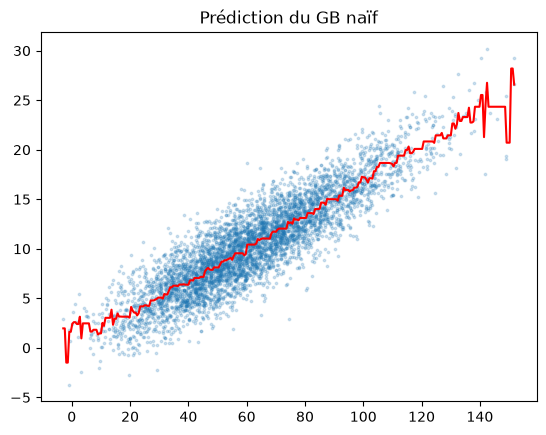

In [10]:
grille = pd.DataFrame({"glaces": np.linspace(df.glaces.min(), df.glaces.max(), 300)})
plt.scatter(df.glaces, df.noyades, s=3, alpha=0.2)
plt.plot(grille.glaces, gb.predict(grille), color="red")
plt.title("Prédiction du GB naïf")
plt.show()

Bonne figure pour le README : le modèle colle bien aux données (il prédit bien), et la courbe monte.

## 4. OLS naïf

In [11]:
ols_naif = sm.OLS(df.noyades, sm.add_constant(df[["glaces"]])).fit()
print(ols_naif.params.round(4))
print(ols_naif.conf_int().loc["glaces"].round(4).tolist())

const    -0.0789
glaces    0.1691
dtype: float64
[0.1667, 0.1716]


Biaisé, IC très étroit autour de la mauvaise valeur : la précision n'est pas l'exactitude.

## 5. OLS en contrôlant la température (avec le carré)

In [12]:
X_ctrl = df[["glaces", "temperature"]].assign(temperature2=df.temperature**2)
ols_ctrl = sm.OLS(df.noyades, sm.add_constant(X_ctrl)).fit()
print(ols_ctrl.summary().tables[1])

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1631      0.228      0.714      0.475      -0.284       0.611
glaces           0.0061      0.006      1.072      0.284      -0.005       0.017
temperature      0.2704      0.026     10.465      0.000       0.220       0.321
temperature2     0.0102      0.001     15.900      0.000       0.009       0.011


Effet des glaces ≈ 0, IC qui contient 0. Et si on oublie le terme au carré ?

In [13]:
ols_lin = sm.OLS(df.noyades, sm.add_constant(df[["glaces", "temperature"]])).fit()
print(ols_lin.params.round(4))
print(ols_lin.conf_int().loc["glaces"].round(4).tolist())

const         -2.7772
glaces         0.0468
temperature    0.5132
dtype: float64
[0.0365, 0.057]


Avec une forme fonctionnelle fausse, il reste un biais : les glaces (qui contiennent du T²) servent de proxy
pour le T² oublié. L'OLS dépend de la bonne spécification → c'est exactement la motivation du Double ML.
À mettre dans les limites + dans le tableau comme ligne supplémentaire ? Je l'ajoute au tableau final,
c'est instructif.

## 6. Double ML
Je regarde d'abord l'API de la version installée.

In [14]:
print(dml.__version__)
print(inspect.signature(dml.DoubleMLPLR))
print(inspect.signature(dml.DoubleMLData))

0.11.4
(obj_dml_data, ml_l, ml_m, ml_g=None, n_folds=5, n_rep=1, score='partialling out', draw_sample_splitting=True)
(data, y_col, d_cols, x_cols=None, z_cols=None, cluster_cols=None, use_other_treat_as_covariate=True, force_all_x_finite=True, force_all_d_finite=True)


In [15]:
def double_ml(df, n_estimators=200, min_samples_leaf=5, seed=0):
    donnees = dml.DoubleMLData(df, y_col="noyades", d_cols="glaces", x_cols=["temperature"])
    ml_l = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=-1)
    ml_m = RandomForestRegressor(n_estimators=n_estimators, min_samples_leaf=min_samples_leaf, random_state=seed, n_jobs=-1)
    np.random.seed(seed)  # le découpage en folds de DoubleML utilise le générateur global de numpy
    modele = dml.DoubleMLPLR(donnees, ml_l, ml_m, n_folds=5)
    modele.fit()
    return modele

debut = time.time()
modele = double_ml(df)
print("temps :", round(time.time() - debut, 1), "s")
modele.summary

temps : 4.2 s


,coef,std err,t,P>|t|,2.5 %,97.5 %
glaces,0.003582,0.005875,0.609827,0.541977,-0.007931,0.015096


In [16]:
modele.confint()

,2.5 %,97.5 %
glaces,-0.007931,0.015096


Effet ≈ 0 avec un IC à 95 % qui contient 0.

Reproductibilité : je relance avec la même seed, ça doit donner exactement le même chiffre.

In [17]:
print(double_ml(df).coef, double_ml(df).coef)

[0.00358245] [0.00358245]


Sensibilité aux hyperparamètres de la forêt (min_samples_leaf) :

In [18]:
for leaf in [1, 5, 20, 50]:
    m = double_ml(df, n_estimators=100, min_samples_leaf=leaf)
    print(leaf, m.coef.round(4), m.se.round(4))

1 [0.0008] [0.0058]


5 [0.0037] [0.0059]


20 [0.0076] [0.0059]


50 [0.0177] [0.0061]


Peu sensible tant que les feuilles restent petites. Avec min_samples_leaf = 50 la forêt est trop lisse,
elle capte moins bien la courbure en T² et un petit biais apparaît (~0.018). Je garde 200 arbres,
min_samples_leaf = 5.

## 7. Robustesse (pour fixer le seuil des tests à ± 0.05)
Le test demandé : |effet DML - effet vrai| < 0.05. L'écart-type est de l'ordre de 0.006, donc 0.05 c'est
~8 écarts-types. Vérification sur quelques seeds de données différentes, pour effet = 0 et effet = 0.5 :

In [19]:
lignes = []
for effet in [0.0, 0.5]:
    for s in range(5):
        d = simuler(effet=effet, seed=1000 + s)
        m = double_ml(d, n_estimators=100, seed=s)
        lignes.append({"effet_vrai": effet, "seed": 1000 + s, "estimation": m.coef[0], "se": m.se[0]})
robustesse = pd.DataFrame(lignes)
robustesse["ecart"] = robustesse.estimation - robustesse.effet_vrai
robustesse.round(4)

,effet_vrai,seed,estimation,se,ecart
0,0.0,1000,0.0009,0.0057,0.0009
1,0.0,1001,-0.0069,0.0056,-0.0069
2,0.0,1002,-0.0051,0.0057,-0.0051
3,0.0,1003,-0.0004,0.0059,-0.0004
4,0.0,1004,-0.0048,0.0056,-0.0048
5,0.5,1000,0.4991,0.0057,-0.0009
6,0.5,1001,0.4911,0.0056,-0.0089
7,0.5,1002,0.4938,0.0057,-0.0062
8,0.5,1003,0.4968,0.0060,-0.0032
9,0.5,1004,0.4938,0.0056,-0.0062


In [20]:
robustesse.groupby("effet_vrai").ecart.agg(["mean", "max", "min"]).round(4)

,mean,max,min
effet_vrai,,,
0.0,-0.0032,0.0009,-0.0069
0.5,-0.0051,-0.0009,-0.0089


Toujours bien en dessous de 0.05 : le seuil des tests est confortable.

## 8. Effet vrai = 0.5 : comparaison complète

In [21]:
df5 = simuler(effet=0.5)
ols_naif5 = sm.OLS(df5.noyades, sm.add_constant(df5[["glaces"]])).fit().params["glaces"]
X5 = df5[["glaces", "temperature"]].assign(temperature2=df5.temperature**2)
ols_ctrl5 = sm.OLS(df5.noyades, sm.add_constant(X5)).fit().params["glaces"]
dml5 = double_ml(df5).coef[0]
gb5 = GradientBoostingRegressor(random_state=0).fit(df5[["glaces"]], df5.noyades)
X5p = df5[["glaces"]].copy()
X5p["glaces"] += 1
gb5_effet = np.mean(gb5.predict(X5p) - gb5.predict(df5[["glaces"]]))
print("GB naïf :", round(gb5_effet, 4), " OLS naïf :", round(ols_naif5, 4),
      " OLS ctrl :", round(ols_ctrl5, 4), " DML :", round(dml5, 4))

GB naïf : 0.6629  OLS naïf : 0.6691  OLS ctrl : 0.5061  DML : 0.5


Le DML retrouve 0.5 ; les méthodes naïves surestiment (≈ 0.5 + biais de confusion).

## 9. Et un Gradient Boosting AVEC la température ?
Pour vérifier le message « ce n'est pas l'algorithme, c'est la question » : même GB, mais on lui donne le confondeur.

In [22]:
gb_ctrl = GradientBoostingRegressor(random_state=0).fit(df[["glaces", "temperature"]], df.noyades)
Xc = df[["glaces", "temperature"]]
Xc_plus1 = Xc.copy()
Xc_plus1["glaces"] += 1
np.mean(gb_ctrl.predict(Xc_plus1) - gb_ctrl.predict(Xc))

np.float64(0.015470709351318905)

Beaucoup plus proche de 0, mais pas d'intervalle de confiance, et un modèle régularisé n'est pas fait pour
estimer un paramètre sans biais (le DML corrige justement ça avec l'orthogonalisation + cross-fitting).
Intéressant pour le notebook final, je l'ajoute comme ligne « bonus » du tableau.

## 10. Intuition graphique : stratifier par température
Si on compare des jours de même température, le lien glaces → noyades devrait disparaître.

In [23]:
df["tranche"] = pd.qcut(df.temperature, 10)
pentes = df.groupby("tranche", observed=True).apply(
    lambda g: np.polyfit(g.glaces, g.noyades, 1)[0], include_groups=False)
pentes.round(4)

tranche
(-1.398, 12.32]     0.1067
(12.32, 14.942]     0.0261
(14.942, 16.907]    0.0480
(16.907, 18.53]     0.0109
(18.53, 20.042]     0.0543
(20.042, 21.561]    0.0222
(21.561, 23.181]    0.0198
(23.181, 25.16]     0.0114
(25.16, 27.77]      0.0778
(27.77, 38.977]     0.1521
dtype: float64

Les pentes à l'intérieur des tranches sont bien plus faibles que 0.17 (entre 0.01 et 0.08 au centre), mais pas
nulles : la température varie encore un peu dans chaque tranche, donc il reste de la confusion résiduelle.
C'est flagrant dans les tranches extrêmes, beaucoup plus larges (0.11 et 0.15). Stratifier grossièrement
ne suffit pas : il faut contrôler la température finement (OLS bien spécifié ou DML).
Bonne figure pédagogique : nuage coloré par tranche + droites intra-tranche.

## Bilan pour `src/`
- `simulation.py` : `simuler_glaces_noyades(n, effet, seed)`.
- `analyse.py` : une fonction par méthode, chacune renvoie un dict (méthode, effet, IC bas, IC haut) ;
  puis `tableau_comparatif(df, effet_vrai)`. GB : R² CV en plus. DML : RF 200 arbres, min_samples_leaf=5.
  Lignes en plus : OLS température sans le carré (forme fonctionnelle fausse) et GB avec température.
- `graphiques.py` : DAG, relations avec la température, nuage coloré, prédiction GB, stratification,
  estimations + IC (effet 0 et 0.5).
- Tests : seuil ± 0.05 confortable (écarts observés de l'ordre de 0.01).